In [ ]:
# TASK 1

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Loaded the parquet data file of the month of July 2025 
raw_data = pd.read_parquet("./yellow_tripdata_2025-07.parquet")
cleaned_data = raw_data.copy()

# Converting the datetime columns from datetime64[us] to datetime64[ns]
cleaned_data["tpep_pickup_datetime"] = cleaned_data["tpep_pickup_datetime"].astype("datetime64[ns]")
cleaned_data["tpep_dropoff_datetime"] = cleaned_data["tpep_dropoff_datetime"].astype("datetime64[ns]")

# print(cleaned_data["tpep_pickup_datetime"].dtype)
print(f"Number of NaN values in tpep_pickup_datetime: {cleaned_data['tpep_pickup_datetime'].isna().sum()}") # verification of NaN from the time format conversion
print(f"Number of NaN values in tpep_dropoff_datetime: {cleaned_data['tpep_dropoff_datetime'].isna().sum()}") # verification of NaN from the time format conversion

# cleaned_data.info()



Number of NaN values in tpep_pickup_datetime: 0
Number of NaN values in tpep_dropoff_datetime: 0


In [26]:
# Removal of trips where pickup time is not strictly before dropoff time.
cleaned_data = cleaned_data[cleaned_data["tpep_dropoff_datetime"] > cleaned_data["tpep_pickup_datetime"]]

# Removal of trips with non-positive distance
cleaned_data = cleaned_data[cleaned_data["trip_distance"] > 0]

# Robust quantile upper bound rule
Q1 = cleaned_data["trip_distance"].quantile(0.25)
Q3 = cleaned_data["trip_distance"].quantile(0.75)
IQR = Q3 - Q1

# Upper bound definition
upper_bound = Q3 + 1.5 * IQR

# Removal of extreme outliers
cleaned_data = cleaned_data[cleaned_data["trip_distance"] <= upper_bound]

# Negative fare and total amount removal
cleaned_data = cleaned_data[(cleaned_data["fare_amount"] > 0) & (cleaned_data["total_amount"] > 0)]


cleaned_data.info()

<class 'pandas.DataFrame'>
Index: 3098946 entries, 0 to 3898962
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float64       


In [27]:
# Removal of impossible passenger count - In Ireland, the maximum number of passengers allowed is 8, excluding the driver
cleaned_data = cleaned_data[cleaned_data["passenger_count"].between(1,8)]
cleaned_data.info()

<class 'pandas.DataFrame'>
Index: 2356772 entries, 0 to 2860206
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float64       


In [28]:
# Calculation of trip duration in minutes 
cleaned_data["trip_minutes"] = (cleaned_data["tpep_dropoff_datetime"] - cleaned_data["tpep_pickup_datetime"]).dt.total_seconds() / 60

# Robust quantile upper bound rule for trip minutes
Q1 = cleaned_data["trip_minutes"].quantile(0.25)
Q3 = cleaned_data["trip_minutes"].quantile(0.75)
IQR = Q3 - Q1

# Upper bound definition
upper_bound = Q3 + 1.5 * IQR

# Removal of extreme minutes outliers
cleaned_data = cleaned_data[cleaned_data["trip_minutes"] <= upper_bound]



# Calculation of speed in miles per hour
cleaned_data["speed_mph"] = (cleaned_data["trip_distance"] / cleaned_data["trip_minutes"]) * 60 

# Robust quantile upper bound rule for trip minutes
Q1 = cleaned_data["speed_mph"].quantile(0.25)
Q3 = cleaned_data["speed_mph"].quantile(0.75)
IQR = Q3 - Q1

# Upper bound definition
upper_bound = Q3 + 1.5 * IQR

# Removal of extreme outliers
cleaned_data = cleaned_data[cleaned_data["speed_mph"] <= upper_bound]

 
# Pick up date
cleaned_data["pickup_date"] = cleaned_data["tpep_pickup_datetime"].dt.date

# Pick up hour
cleaned_data["pickup_hour"] = cleaned_data["tpep_pickup_datetime"].dt.hour

# Reset index and display information
cleaned_data = cleaned_data.reset_index(drop=True)
print(cleaned_data["trip_distance"].describe().round(2))
print(cleaned_data["trip_minutes"].describe().round(2))
print(cleaned_data["speed_mph"].describe().round(2))


count    2189706.00
mean           1.84
std            1.32
min            0.01
25%            0.92
50%            1.48
75%            2.33
max            8.45
Name: trip_distance, dtype: float64
count    2189706.00
mean          12.36
std            6.87
min            0.03
25%            7.02
50%           11.02
75%           16.55
max           32.55
Name: trip_minutes, dtype: float64
count    2189706.00
mean           9.09
std            3.43
min            0.02
25%            6.63
50%            8.74
75%           11.19
max           18.96
Name: speed_mph, dtype: float64


In [41]:
# Data summary

raw_data_length = len(raw_data)
cleaned_data_length = len(cleaned_data)
percent_dropped = (raw_data_length - cleaned_data_length) / raw_data_length * 100
median_trip_minutes = cleaned_data["trip_minutes"].median()
median_speed_mph = cleaned_data["speed_mph"].median()

#For NYC Yellow Taxi data, the official mapping is:
# 0 = Flex Fare trip 
# 1 = Credit card
# 2 = Cash
# 3 = No charge
# 4 = Dispute
# 5 = Unknown
# 6 = Voided trip

share_card = (cleaned_data["payment_type"] == 1).mean()
share_cash = (cleaned_data["payment_type"] == 2).mean()

summary = pd.DataFrame({
    "Metric": ["Raw Data Length", "Cleaned Data Length", "Percent Dropped", "Median Trip Minutes", "Median Speed MPH", "Share Cash", "Share Card"],
    "Value": [raw_data_length, cleaned_data_length, percent_dropped, median_trip_minutes, median_speed_mph, share_cash, share_card]
})

summary["Value"] = summary["Value"].apply(
    lambda x: int(x) if x >= 1 else round(x, 2)
)
os.makedirs("./outputs", exist_ok=True)

summary.to_csv("outputs/task1_summary.csv", index=False)

count    2189706.00
mean           9.09
std            3.43
min            0.02
25%            6.63
50%            8.74
75%           11.19
max           18.96
Name: speed_mph, dtype: float64


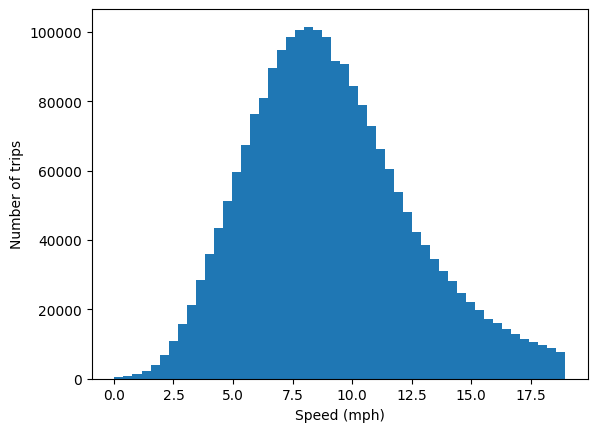

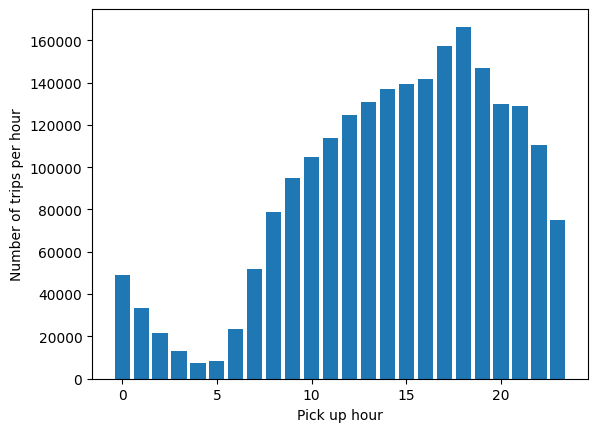

In [38]:
os.makedirs("./outputs", exist_ok=True)
print(cleaned_data["speed_mph"].describe().round(2))
plt.hist(cleaned_data["speed_mph"].round(2), bins=50)
plt.xlabel("Speed (mph)")
plt.ylabel("Number of trips")
plt.savefig("./outputs/task1_speed_hist.png")
plt.show()


hour_counts = cleaned_data["pickup_hour"].value_counts().sort_index()
plt.bar(hour_counts.index, hour_counts.values)
plt.xlabel("Pick up hour")
plt.ylabel("Number of trips per hour")
plt.savefig("./outputs/task1_hourly_volume.png")
plt.show()

In [ ]:
# TASK2

lookup_data = pd.read_csv("./taxi_zone_lookup.csv")
lookup_data.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone
